In [1]:
import sys
import os

sys.argv = ['']
sys.path.append("..")

import numpy as np
import random
from collections import deque
from typing import List, Tuple, Any, Optional
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from rl_algorithms.agent import Agent
from env.env import Env


import torch
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn

In [2]:
def state_to_idx_tensor(state, y_dim, device):
    """
    将状态转换为 state idx 张量
    :param state: 单个状态 (x, y) 或批量状态数组 (batch, 2)
    :return: state idx tensor，单个状态返回形状 (1,)，批量状态返回形状 (batch,)
    """
    if isinstance(state, (tuple, list, np.ndarray)) and len(state) == 2 and isinstance(state[0], (int, np.integer)):
        # 单个状态 (x, y)
        state_idx = int(state[0]) * y_dim + int(state[1])
        state_idx_tensor = torch.tensor(
            [state_idx], dtype=torch.long, device=device)
    else:
        # 批量状态 (batch, 2)
        state = np.array(state, dtype=np.int64)
        state_indices = state[:, 0] * y_dim + state[:, 1]
        state_idx_tensor = torch.tensor(
            state_indices, dtype=torch.long, device=device)
    return state_idx_tensor

In [3]:
state_test = torch.tensor([(1,2)])
state_test_idx = state_to_idx_tensor(state_test, 10, 'cpu')
print(state_test_idx)


tensor([12])


In [4]:
def idx_tensor_to_state(idx_tensor, y_dim):
    """
    将 state idx 张量转换为状态
    :param idx_tensor: state idx tensor，单个状态返回形状 (1,) 或标量，批量状态返回形状 (batch,)
    :param y_dim: 环境 y 维度
    :return: 状态数组，单个状态返回形状 (2,)，批量状态返回形状 (batch, 2)
    """
    # 转换为 numpy 数组以便处理
    if isinstance(idx_tensor, torch.Tensor):
        idx_array = idx_tensor.cpu().numpy()
    elif isinstance(idx_tensor, (int, np.integer)):
        # 单个标量
        idx_array = np.array([idx_tensor])
    else:
        idx_array = np.array(idx_tensor)
    
    # 确保是一维数组
    if idx_array.ndim == 0:
        idx_array = idx_array.reshape(1)
    
    # 计算状态坐标
    state_x = idx_array // y_dim
    state_y = idx_array % y_dim
    
    # 判断是单个状态还是批量状态
    if len(idx_array) == 1:
        # 单个状态 (x, y)
        state = np.array([int(state_x[0]), int(state_y[0])], dtype=np.int64)
    else:
        # 批量状态 (batch, 2)
        state = np.stack([state_x, state_y], axis=1).astype(np.int64)
    
    return state

In [5]:
state_idx_test = torch.tensor([12,13,14])
state_test = idx_tensor_to_state(state_idx_test, 10)
print(state_test)


[[1 2]
 [1 3]
 [1 4]]


In [6]:
def calculate_distance(state_idx, targets_idx, y_dim=10, x_dim=10, device='cpu'):
    """
    计算状态到目标的距离信息
    支持两种模式：
    1. 批量模式：state_idx 和 targets_idx 形状相同 (B,)，每个样本的 state 对应一个 target
    2. 多目标模式：state_idx 是单个值，targets_idx 是多个值 (num_targets,)，计算单个 state 到多个 targets 的距离
    
    :param state_idx: 状态索引，torch.Tensor 形状 (B,) 或 (1,) 或标量
    :param targets_idx: 目标索引，torch.Tensor 形状 (B,) 或 (num_targets,)
    :param y_dim: 环境 y 维度
    :param x_dim: 环境 x 维度
    :param device: 设备
    :return: 字典，包含 state_idx, targets_idx 和所有距离特征
    """
    # 确保 state_idx 和 targets_idx 是 torch.Tensor
    if not isinstance(state_idx, torch.Tensor):
        state_idx = torch.tensor([state_idx] if isinstance(state_idx, (int, np.integer)) else state_idx, device=device)
    if not isinstance(targets_idx, torch.Tensor):
        targets_idx = torch.tensor(targets_idx, device=device)
    
    # 确保在正确的设备上
    state_idx = state_idx.to(device)
    targets_idx = targets_idx.to(device)
    
    # 转换为状态坐标
    state = idx_tensor_to_state(state_idx, y_dim)  # 单个状态: (2,), 批量状态: (B, 2)
    targets = idx_tensor_to_state(targets_idx, y_dim)  # 单个目标: (2,), 批量目标: (B, 2) 或 (num_targets, 2)
    
    # 转换为 torch tensor
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
    targets_tensor = torch.tensor(targets, dtype=torch.float32, device=device)
    
    # 判断处理模式
    if state_tensor.ndim == 1 and state_tensor.shape[0] == 2:
        # 单个 state 模式
        if targets_tensor.ndim == 1 and targets_tensor.shape[0] == 2:
            # 单个 state 到单个 target
            state_expanded = state_tensor.unsqueeze(0)  # (1, 2)
            targets_expanded = targets_tensor.unsqueeze(0)  # (1, 2)
            dx = (targets_expanded[:, 0] - state_expanded[0, 0])  # (1,)
            dy = (targets_expanded[:, 1] - state_expanded[0, 1])  # (1,)
        else:
            # 单个 state 到多个 targets
            state_expanded = state_tensor.unsqueeze(0)  # (1, 2)
            dx = (targets_tensor[:, 0] - state_expanded[0, 0])  # (num_targets,)
            dy = (targets_tensor[:, 1] - state_expanded[0, 1])  # (num_targets,)
    else:
        # 批量模式：state 和 target 数量相同
        dx = (targets_tensor[:, 0] - state_tensor[:, 0])  # (B,)
        dy = (targets_tensor[:, 1] - state_tensor[:, 1])  # (B,)
    
    # 归一化
    dx_n = dx / x_dim
    dy_n = dy / y_dim
    
    # 计算距离特征
    abs_dx = torch.abs(dx_n)
    abs_dy = torch.abs(dy_n)
    l1 = abs_dx + abs_dy
    l2 = torch.sqrt(dx_n ** 2 + dy_n ** 2 + 1e-8)
    sign_dx = torch.sign(dx_n)
    sign_dy = torch.sign(dy_n)
    
    # 返回包含 state_idx 和所有 target 距离信息的字典
    return {
        'state_idx': state_idx,
        'targets_idx': targets_idx,
        'state_coord': state_tensor,
        'targets_coord': targets_tensor,
        'dx_n': dx_n,
        'dy_n': dy_n,
        'abs_dx': abs_dx,
        'abs_dy': abs_dy,
        'l1': l1,
        'l2': l2,
        'sign_dx': sign_dx,
        'sign_dy': sign_dy,
    }


In [7]:
state_idx_test = torch.tensor([12])
targets_idx_test = torch.tensor([13,14,15])
distance_info = calculate_distance(state_idx_test, targets_idx_test)
print("State idx:", distance_info['state_idx'])
print("Targets idx:", distance_info['targets_idx'])
print("State coord:", distance_info['state_coord'])
print("Targets coord:", distance_info['targets_coord'])
print("L1 distance:", distance_info['l1'])
print("L2 distance:", distance_info['l2'])
print("All distance features:")
for key, value in distance_info.items():
    if key not in ['state_idx', 'targets_idx', 'state_coord', 'targets_coord']:
        print(f"  {key}: {value}")


State idx: tensor([12])
Targets idx: tensor([13, 14, 15])
State coord: tensor([1., 2.])
Targets coord: tensor([[1., 3.],
        [1., 4.],
        [1., 5.]])
L1 distance: tensor([0.1000, 0.2000, 0.3000])
L2 distance: tensor([0.1000, 0.2000, 0.3000])
All distance features:
  dx_n: tensor([0., 0., 0.])
  dy_n: tensor([0.1000, 0.2000, 0.3000])
  abs_dx: tensor([0., 0., 0.])
  abs_dy: tensor([0.1000, 0.2000, 0.3000])
  l1: tensor([0.1000, 0.2000, 0.3000])
  l2: tensor([0.1000, 0.2000, 0.3000])
  sign_dx: tensor([0., 0., 0.])
  sign_dy: tensor([1., 1., 1.])


In [8]:
class Qnet(nn.Module):
    """
    Q(s, a | target)

    target 通过 embedding 输入网络
    相对位置信息作为主干
    """

    def __init__(
        self,
        state_num: int,
        action_dim: int,
        x_dim: int,
        y_dim: int,
        embedding_dim: int = 32,
        hidden_dim: int = 128,
    ):
        super().__init__()

        self.x_dim = x_dim
        self.y_dim = y_dim

        # ===== state embedding =====
        self.embedding = nn.Embedding(state_num, embedding_dim)

        self.abs_fc = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== target embedding branch =====
        self.target_fc = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== relative position branch（主干）=====
        self.rel_fc = nn.Sequential(
            nn.Linear(8, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # ===== fusion head =====
        # 融合 state embedding, target embedding 和 relative position (64 + 64 + 64 = 192)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, state_idx: torch.Tensor, target_idx: torch.Tensor):
        """
        state_idx: (B,)
        target_idx: (B,)
        """

        # ===== absolute state embedding =====
        state_emb = self.embedding(state_idx)
        h_abs = self.abs_fc(state_emb)

        # ===== target embedding =====
        target_emb = self.embedding(target_idx)
        h_target = self.target_fc(target_emb)

        # ===== relative position to target using calculate_distance =====
        # 使用 calculate_distance 计算相对位置特征（批量处理）
        device = state_idx.device
        distance_info = calculate_distance(
            state_idx, 
            target_idx, 
            y_dim=self.y_dim, 
            x_dim=self.x_dim, 
            device=device
        )
        
        # 提取相对位置特征并堆叠 (B, 8)
        rel_feat = torch.stack([
            distance_info['dx_n'],
            distance_info['dy_n'],
            distance_info['abs_dx'],
            distance_info['abs_dy'],
            distance_info['l1'],
            distance_info['l2'],
            distance_info['sign_dx'],
            distance_info['sign_dy'],
        ], dim=1)  # (B, 8)

        h_rel = self.rel_fc(rel_feat)

        # ===== fusion =====
        h = torch.cat([h_abs, h_target, h_rel], dim=1)
        q = self.head(h)

        return q

In [9]:
class ReplayBuffer:
    """
    ReplayBuffer，用于存储经验
    """

    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

In [14]:
class DQN(Agent):
    def __init__(self, env, agent_id = None,
                 lr = 0.001, gamma = 0.99, iteration = 10,
                 epsilon = 1.0, epsilon_min = 0.01, epsilon_decay = 0.995,
                 num_episodes = 10, episode_length = 400000,
                 batch_size = 64, mini_batch_size = 32,
                 hidden_dim = 128, update_freq = 100):
        super().__init__(env=env, 
                         lr=lr, gamma=gamma, 
                         epsilon=epsilon, epsilon_min=epsilon_min, 
                         epsilon_decay=epsilon_decay, num_episodes=num_episodes, episode_length=episode_length)
        
        self.agent_id = agent_id
        self.iteration = iteration
        
        # 初始化经验回放缓冲区
        self.buffer = ReplayBuffer(episode_length * num_episodes * env.num_agents)
        self.batch_size = batch_size
        self.mini_batch_size = mini_batch_size
        
        self.hidden_dim = hidden_dim
        
        # 初始化Q网络和目标Q网络
        state_num = env.state_num # 总状态数
        self.qnet = Qnet(state_num = state_num, embedding_dim = 64, hidden_dim = hidden_dim, 
                         action_dim = env.num_actions, x_dim = env.x_dim, y_dim = env.y_dim)
        self.target_qnet = Qnet(state_num = state_num, embedding_dim = 64, hidden_dim = hidden_dim, 
                                action_dim = env.num_actions, x_dim = env.x_dim, y_dim = env.y_dim)
        self.target_qnet.load_state_dict(self.qnet.state_dict())
        self.target_qnet.eval()
        
        # 初始化优化器和损失函数
        self.optimizer = optim.Adam(self.qnet.parameters(), lr = lr)
        self.loss_fn = nn.MSELoss()
        
        # 初始化设备
        self.device = torch.device("cpu")
        self.qnet.to(self.device)
        self.target_qnet.to(self.device)
        
        self.update_freq = update_freq
    
    
    
    def take_action(self, state, training = True):
        """
        选择动作
        :param state: 状态
        :param agent_id: 机器人编号
        :param training: 是否处于训练模式
        :return: action索引（int）
        """
        
        # 获取所有的 target states
        all_targets = self.env.target_states
        num_targets = len(all_targets)
        
        # 将 (x, y) 转换为 state_idx: state_idx = x * y_dim + y
        state_idx_tensor = state_to_idx_tensor(state, self.env.y_dim, self.device)
        
        # 将当前 state 重复多次（与 target 数量相同）
        state_idx_repeated = state_idx_tensor.repeat(num_targets)  # (num_targets,)
        
        # 将所有 targets 转换为 target_idx_tensor
        all_target_idx_tensors = []
        for target in all_targets:
            target_idx_tensor = state_to_idx_tensor(target, self.env.y_dim, self.device)
            all_target_idx_tensors.append(target_idx_tensor)
        target_idx_tensor = torch.cat(all_target_idx_tensors, dim=0)  # (num_targets,)
        
        with torch.no_grad():
            # 计算所有 (state, target) 对的 Q 值，形状为 (num_targets, action_dim)
            action_values = self.qnet(state_idx_repeated, target_idx_tensor)
        
        # 从所有 Q 值中选择最大的 action（在所有 target 和 action 组合中）
        # action_values 形状: (num_targets, action_dim)
        # 找到全局最大的 Q 值对应的 action
        # 方法：对每个 action，取所有 target 下的最大 Q 值，然后选择最大的 action
        max_q_per_action = action_values.max(dim=0)[0]  # (action_dim,) 每个 action 在所有 target 下的最大 Q 值
        optimal_action = max_q_per_action.argmax().item()  # 选择最大 Q 值对应的 action
        
        if training:
            # 概率分配：最优动作概率最大，其他动作概率相同
            # 最优动作概率：1 - epsilon + epsilon/num_actions
            # 其他动作概率：epsilon/num_actions
            num_actions = self.env.num_actions
            probs = torch.full((num_actions,), self.epsilon / num_actions, device=self.device)
            probs[optimal_action] = 1 - self.epsilon + self.epsilon / num_actions
            
            # 根据概率分布采样动作
            dist = torch.distributions.Categorical(probs=probs)
            action = dist.sample().item()
            return action
        else:
            # 测试模式：直接返回最优动作
            return optimal_action
    
    def update(self):
        batch = self.buffer.sample(self.mini_batch_size)

        states = np.array([b[0] for b in batch])
        actions = np.array([b[1] for b in batch])
        rewards = np.array([b[2] for b in batch], dtype=np.float32)
        next_states = np.array([b[3] for b in batch])
        dones = np.array([b[4] for b in batch], dtype=np.float32)

        state_idx = state_to_idx_tensor(states, self.env.y_dim, self.device)
        next_state_idx = state_to_idx_tensor(
            next_states, self.env.y_dim, self.device)

        action_tensor = torch.tensor(actions, dtype=torch.long, device=self.device)
        reward_tensor = torch.tensor(rewards, device=self.device)

        # 将 target 转换为 tensor，并扩展到 batch 大小
        target = self.env.target_states[self.agent_id]
        target_idx_single = state_to_idx_tensor(
            target, self.env.y_dim, self.device)
        target_idx = target_idx_single.repeat(len(batch))

        q = self.qnet(state_idx, target_idx)
        q = q.gather(1, action_tensor.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_qnet(next_state_idx, target_idx)
            max_next_q = next_q.max(dim=1)[0]
            td_target = reward_tensor + self.gamma * max_next_q * (1 - dones)

        loss = self.loss_fn(q, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()
    
    def update_target_qnet(self):
        """同步目标Q网络参数"""
        self.target_qnet.load_state_dict(self.qnet.state_dict())

    def save(self, path: str):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save({
            "qnet": self.qnet.state_dict(),
            "target_qnet": self.target_qnet.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "epsilon": self.epsilon,
        }, path)
        print(f"模型已保存到: {path}")
    
    def load(self, path: str):
        if not os.path.isfile(path):
            raise FileNotFoundError(f"未找到模型文件: {path}")
        checkpoint = torch.load(path, map_location=self.device)
        self.qnet.load_state_dict(checkpoint["qnet"])
        self.target_qnet.load_state_dict(checkpoint.get("target_qnet", checkpoint["qnet"]))
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.epsilon = checkpoint.get("epsilon", self.epsilon)

In [15]:
def train_dqn(env, dqn):
    print(f"Begin to train DQN, iteration: {dqn.iteration}")
    epsilon = dqn.epsilon
    return_list = []
    for i in range(dqn.iteration):
        dqn.epsilon = epsilon
        # 使用tqdm创建进度条
        pbar = tqdm(range(1, dqn.num_episodes + 1),
                    desc=f"Iteration({i+1}) progress".format(i+1), unit="episode")
        for ep in pbar:
            states, _ = env.reset()
            state = states[dqn.agent_id]
            ep_return = 0
            for t in range(dqn.episode_length):
                action_idx = dqn.take_action(state, training=True)
                action = env.action_space[action_idx]
                next_state, reward, done, _ = env.step(action)
                ep_return += reward
                dqn.buffer.add(state, action_idx, reward, next_state, done)
                if len(dqn.buffer) >= dqn.mini_batch_size:
                    dqn.update()
                state = next_state
                if t % dqn.update_freq == 0:
                    dqn.update_target_qnet()
                if done:
                    break
            return_list.append(ep_return)
            # epsilon **按 episode 衰减**
            dqn.epsilon = max(dqn.epsilon_min, dqn.epsilon * dqn.epsilon_decay)
            pbar.set_postfix({
                'Episode': ep,
                'Return': f'{ep_return:.2f}',
                'Epsilon': f'{dqn.epsilon:.3f}'
            })
    return dqn, return_list

In [16]:
env = Env()
dqn =DQN(
            env,
            agent_id=0,
            lr=1e-3,
            gamma=0.99,
            iteration=5,
            epsilon=0.8,
            epsilon_decay=0.9,   # 按 episode
            epsilon_min=0.1,
            num_episodes=50,
            episode_length=35000,
            mini_batch_size=64,
            update_freq=10
        )

dqn, return_list = train_dqn(env, dqn)
dqn.save("../models/dqn_model_test.pth")

Begin to train DQN, iteration: 5


Iteration(1) progress:   0%|          | 0/50 [00:00<?, ?episode/s]

Iteration(5) progress: 100%|██████████| 50/50 [00:08<00:00,  6.02episode/s, Episode=50, Return=-29.00, Epsilon=0.100]

模型已保存到: ../models/dqn_model_test.pth


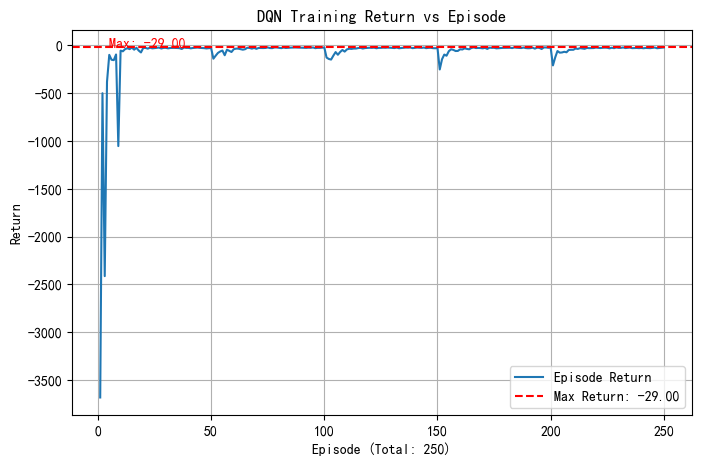

In [17]:
# plot
import matplotlib.pyplot as plt
# 按照 return_list 绘制曲线
total_episodes = dqn.iteration * dqn.num_episodes
max_return = max(return_list)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(return_list)+1), return_list, label="Episode Return")
plt.axhline(y=max_return, color='r', linestyle='--', label=f"Max Return: {max_return:.2f}")
plt.xlabel(f'Episode (Total: {len(return_list)})')
plt.ylabel('Return')
plt.title('DQN Training Return vs Episode')
plt.grid(True)
plt.legend()
# 在图表上标注 max_return 数值
plt.text(len(return_list) * 0.02, max_return * 1.02, f'Max: {max_return:.2f}', 
         fontsize=10, color='r', fontweight='bold')
plt.show()

